FIRST FIVE ROWS
      START_DATE*       END_DATE* CATEGORY*       START*            STOP*  \
0  1/1/2016 21:11  1/1/2016 21:17  Business  Fort Pierce      Fort Pierce   
1   1/2/2016 1:25   1/2/2016 1:37  Business  Fort Pierce      Fort Pierce   
2  1/2/2016 20:25  1/2/2016 20:38  Business  Fort Pierce      Fort Pierce   
3  1/5/2016 17:31  1/5/2016 17:45  Business  Fort Pierce      Fort Pierce   
4  1/6/2016 14:42  1/6/2016 15:49  Business  Fort Pierce  West Palm Beach   

   MILES*         PURPOSE*  
0     5.1   Meal/Entertain  
1     5.0              NaN  
2     4.8  Errand/Supplies  
3     4.7          Meeting  
4    63.7   Customer Visit  

Dataset Shape
(1156, 7)

Column Names
Index(['START_DATE*', 'END_DATE*', 'CATEGORY*', 'START*', 'STOP*', 'MILES*',
       'PURPOSE*'],
      dtype='object')

Missing Values
START_DATE*      0
END_DATE*        1
CATEGORY*        1
START*           1
STOP*            1
MILES*           0
PURPOSE*       503
dtype: int64

Duplicate Rows : 1

Data T

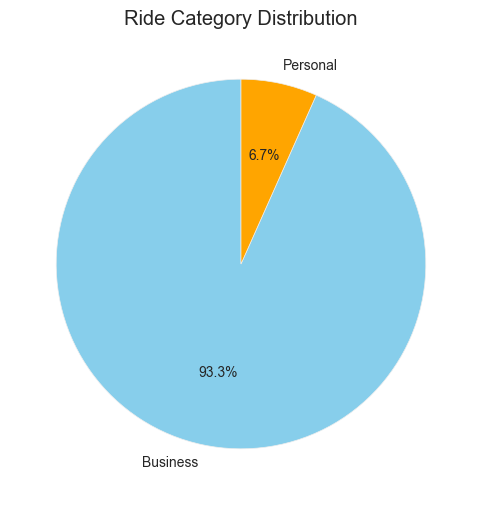

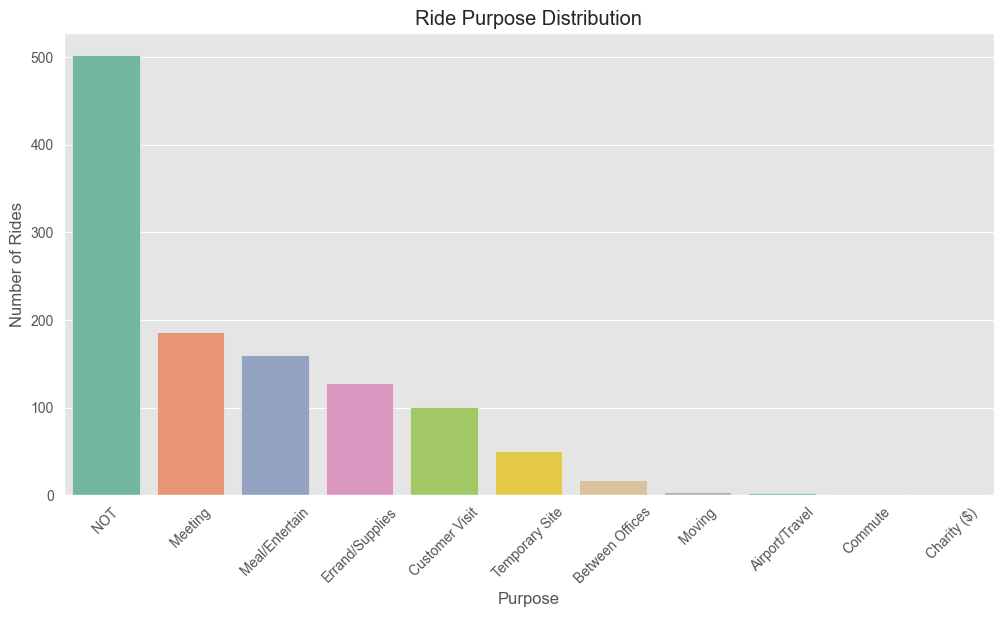

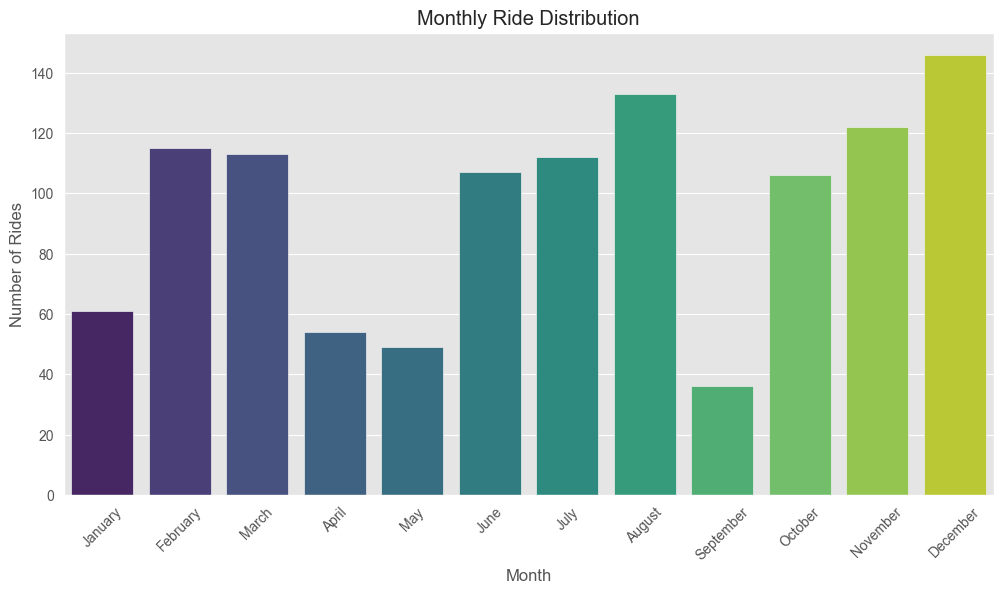

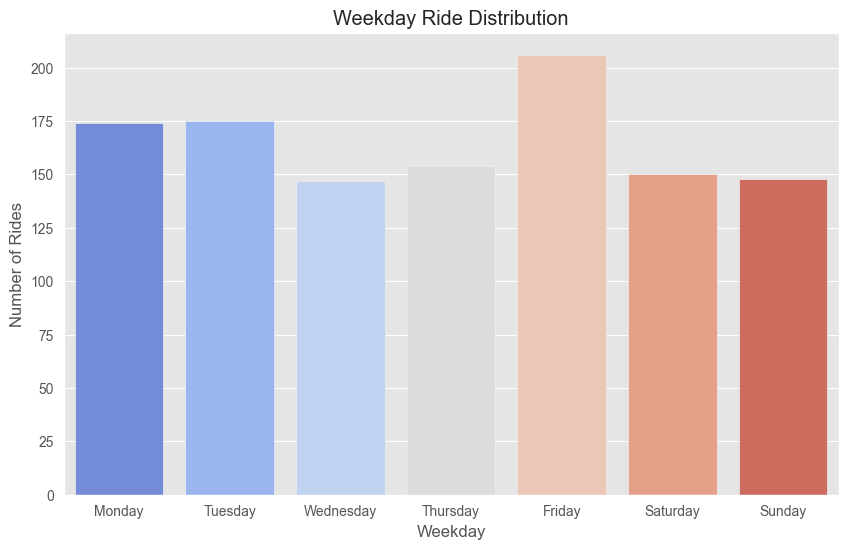

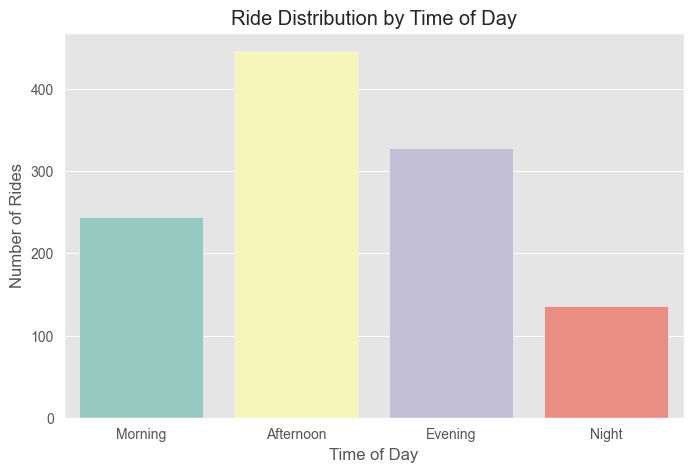

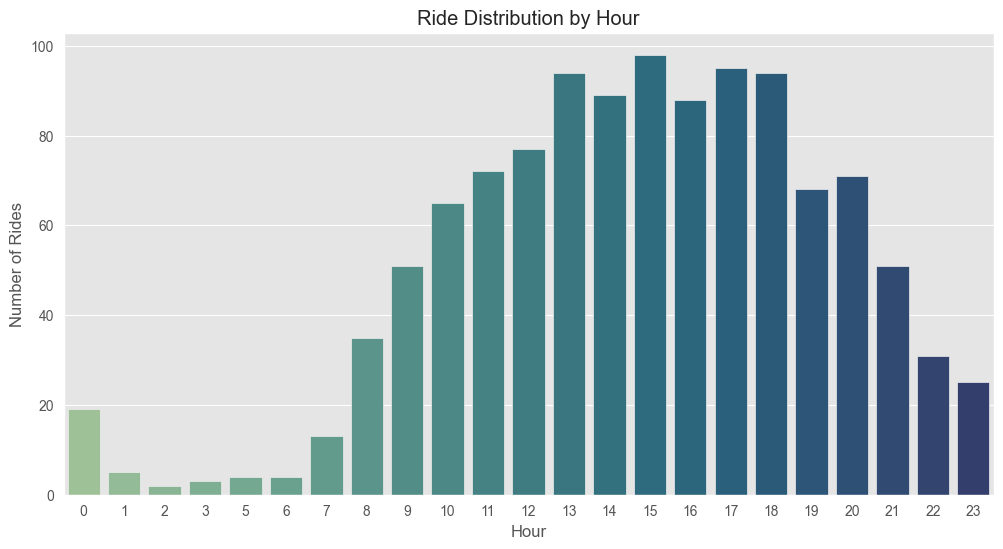

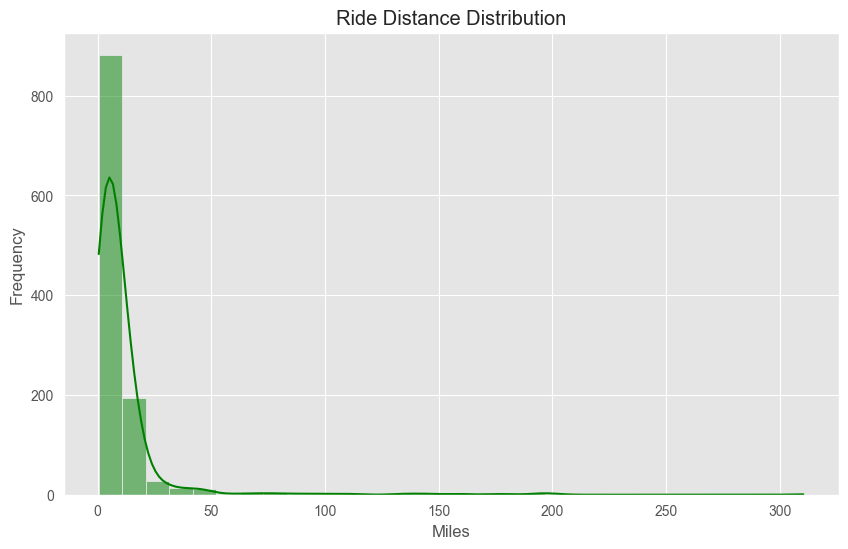

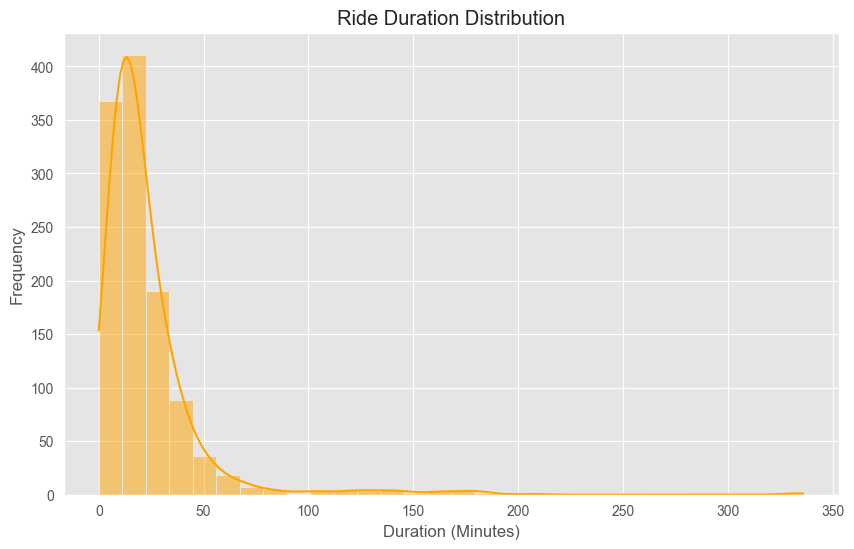

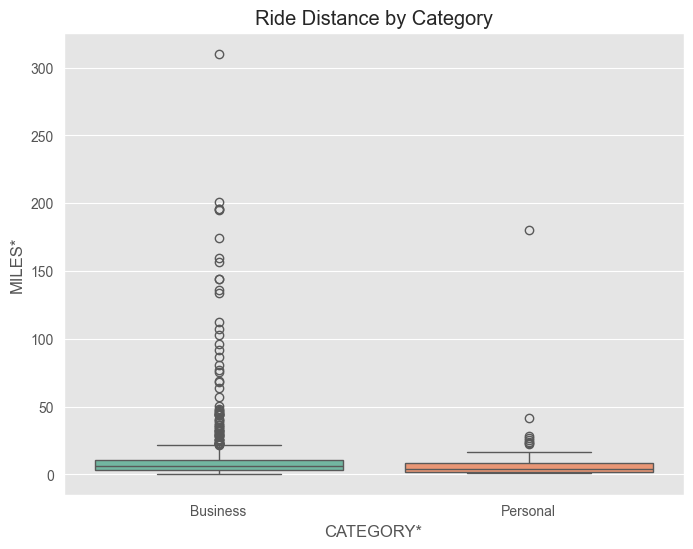

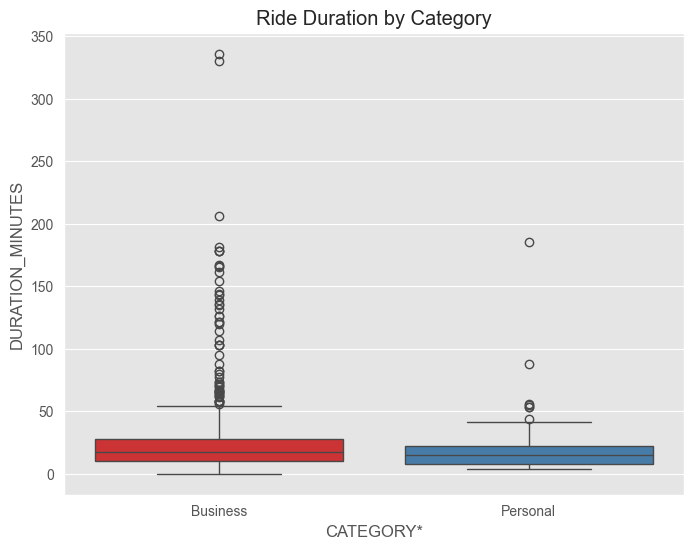

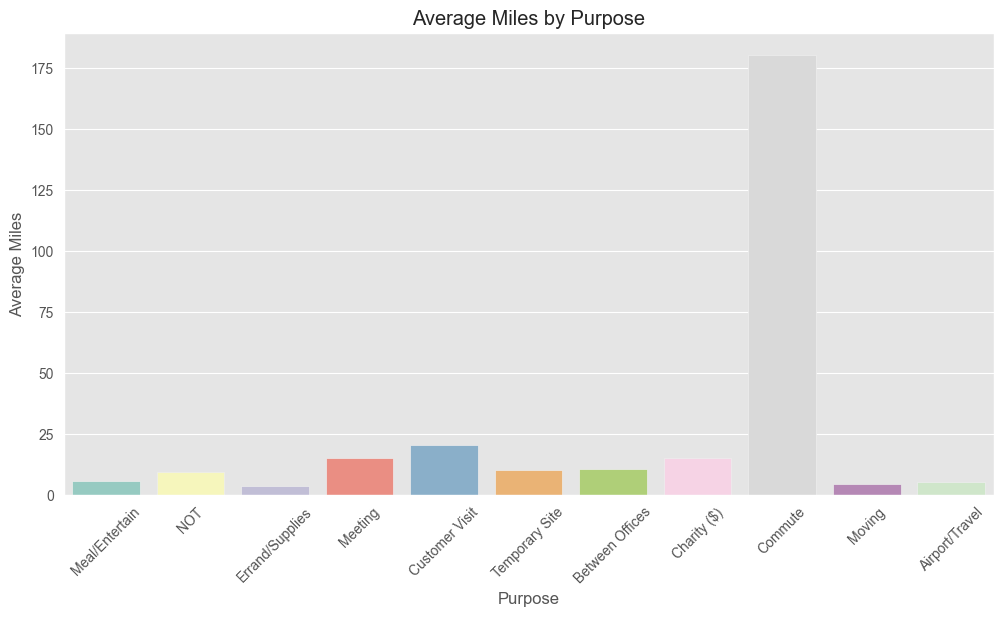

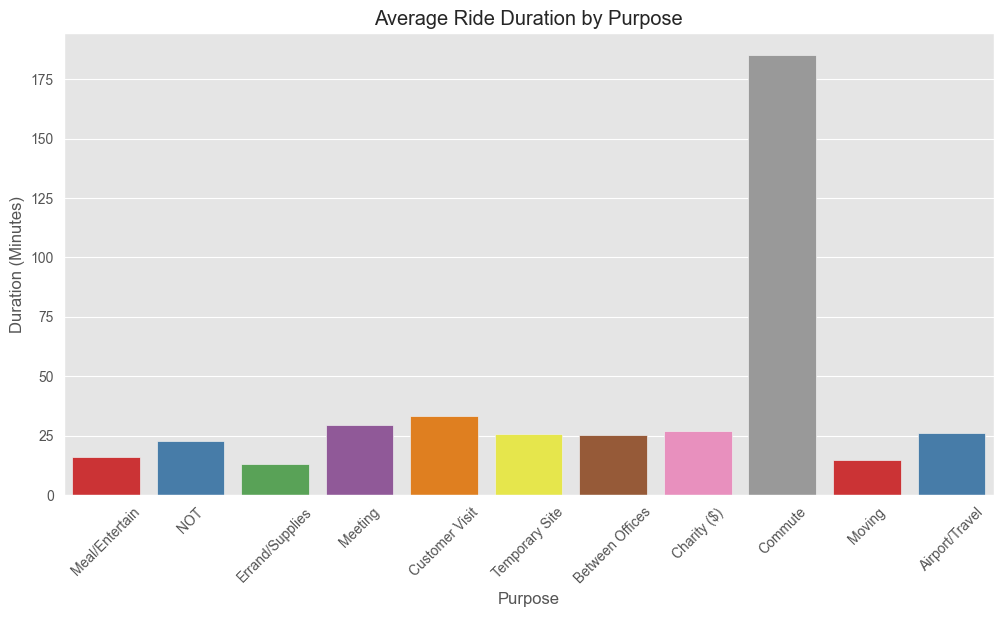

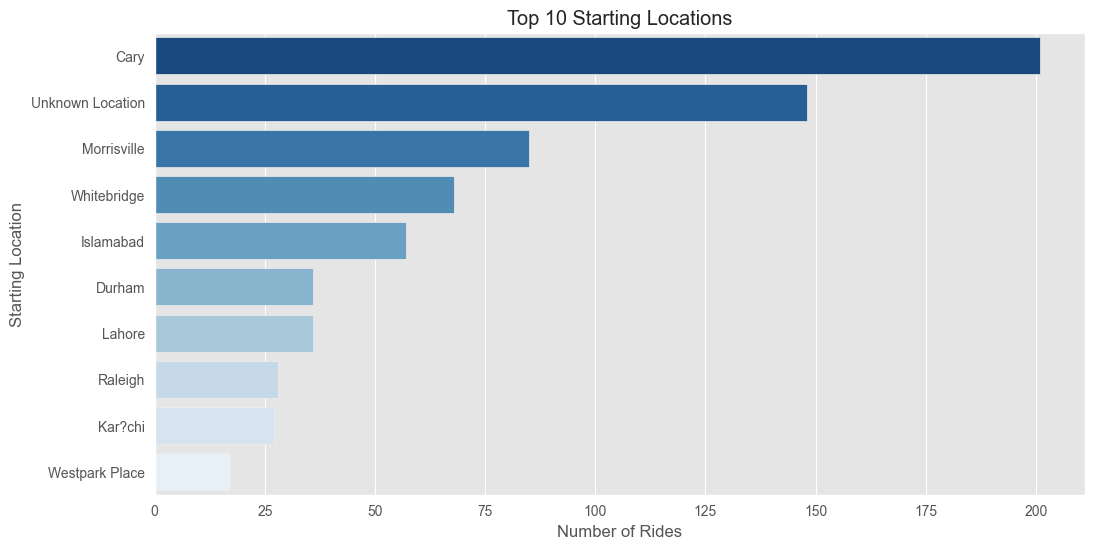

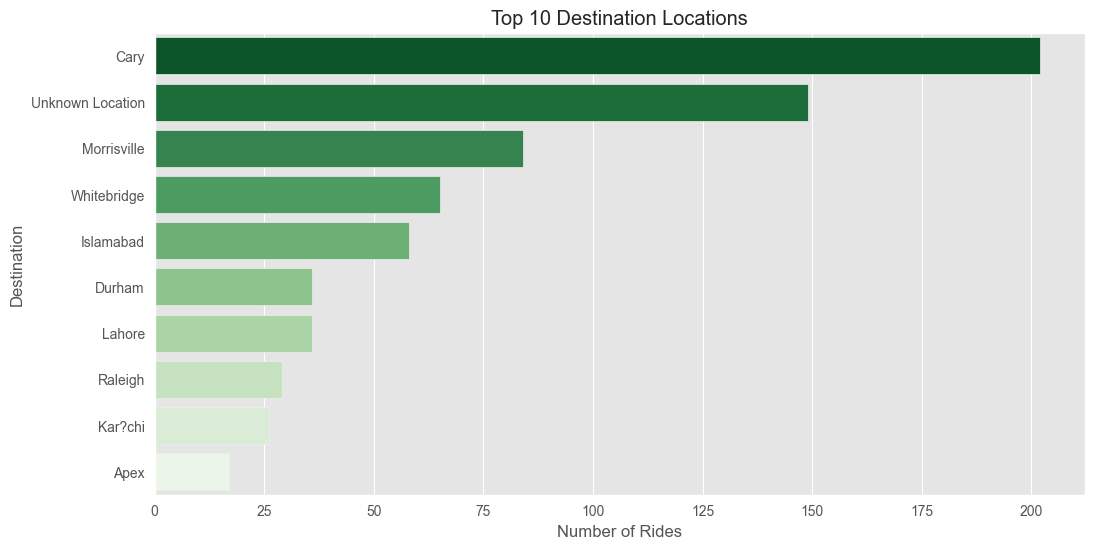

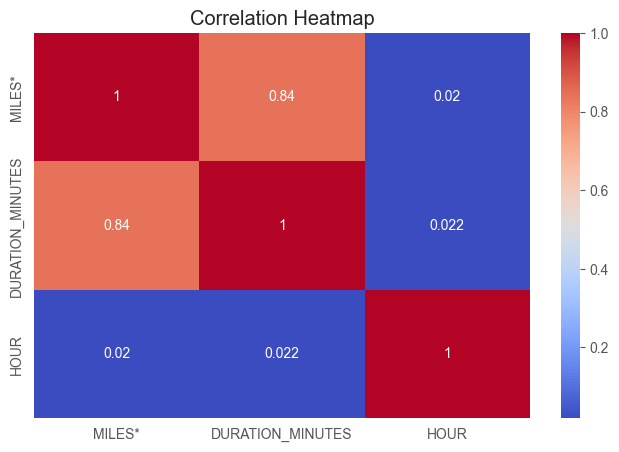

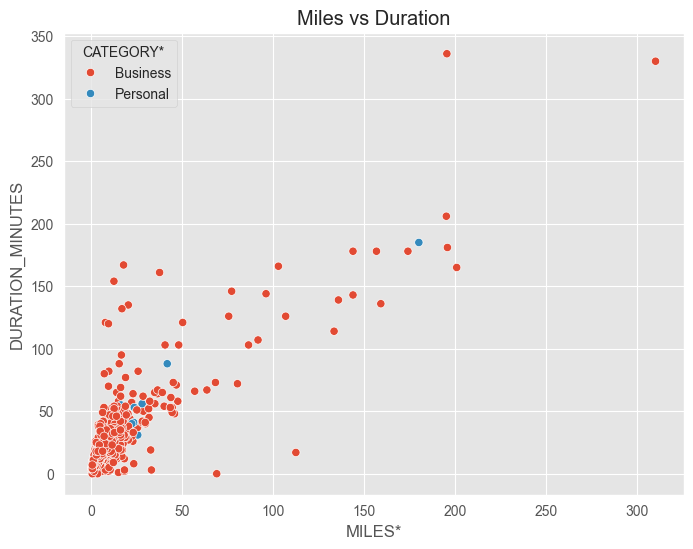

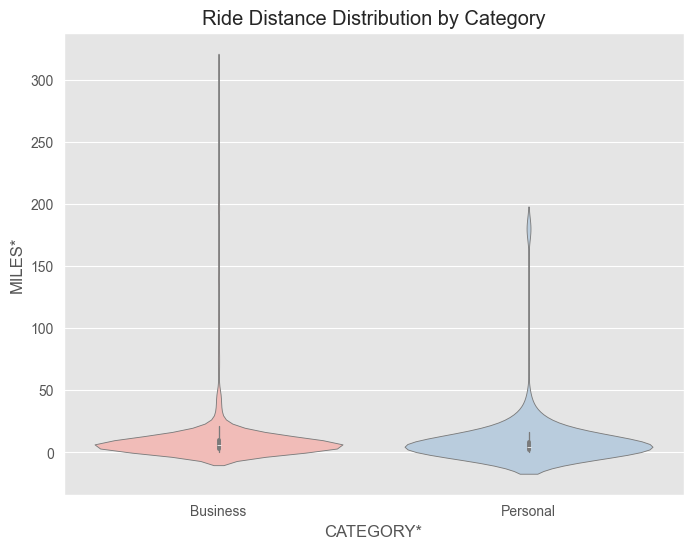

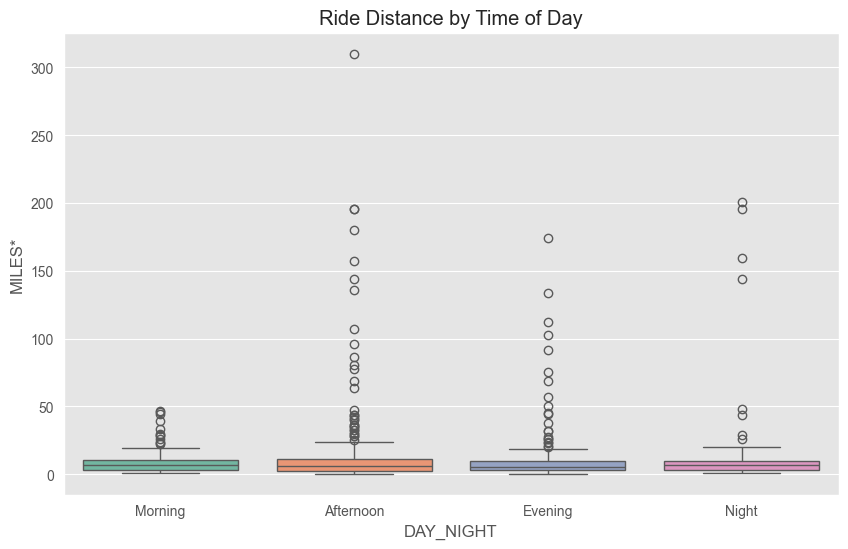

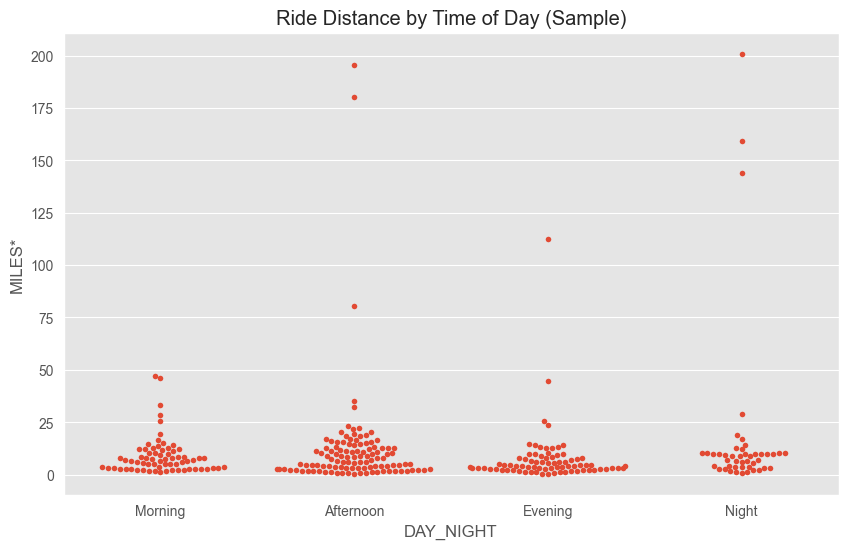

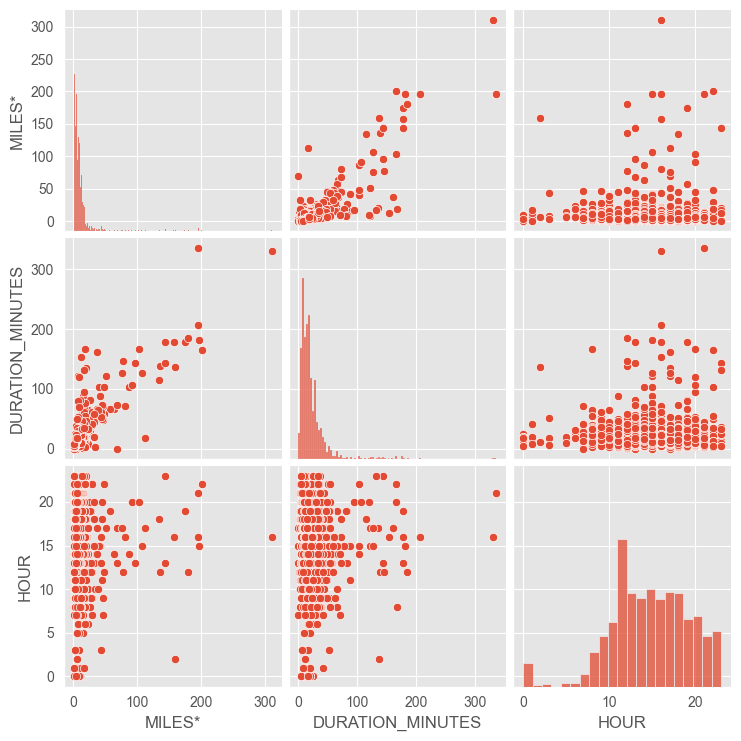

PHASE 2 (EDA) COMPLETED SUCCESSFULLY
PHASE 3 : BUSINESS INSIGHTS

1. Total Number of Rides
1154

2. Ride Category Count
CATEGORY*
Business    1077
Personal      77
Name: count, dtype: int64

3. Ride Category Percentage
CATEGORY*
Business    93.33
Personal     6.67
Name: proportion, dtype: float64

4. Total Distance Travelled
12194.8 Miles

5. Average Ride Distance
10.57 Miles

6. Total Ride Duration
26821.0 Minutes

7. Average Ride Duration
23.24 Minutes

8. Longest Ride
START_DATE*         2016-03-25 16:52:00
END_DATE*           2016-03-25 22:22:00
CATEGORY*                      Business
START*                            Latta
STOP*                      Jacksonville
MILES*                            310.3
PURPOSE*                 Customer Visit
DURATION_MINUTES                  330.0
MONTH                             March
WEEKDAY                          Friday
HOUR                                 16
DAY_NIGHT                     Afternoon
Name: 269, dtype: object

9. Shortest Ride
S

In [11]:
# ==========================================================
# UBER RIDE ANALYSIS PROJECT
# Data Loading & Cleaning
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

# ----------------------------------------------------------
# Load Dataset
# ----------------------------------------------------------

uber_df = pd.read_csv("uber ride dataset.csv")

print("="*60)
print("FIRST FIVE ROWS")
print("="*60)
print(uber_df.head())

print("\nDataset Shape")
print(uber_df.shape)

print("\nColumn Names")
print(uber_df.columns)

print("\nMissing Values")
print(uber_df.isnull().sum())

print("\nDuplicate Rows :", uber_df.duplicated().sum())


# ----------------------------------------------------------
# Remove Duplicate Rows
# ----------------------------------------------------------

uber_df.drop_duplicates(inplace=True)


# ----------------------------------------------------------
# Remove Totals Row (Important)
# ----------------------------------------------------------

uber_df = uber_df[uber_df["START_DATE*"] != "Totals"]


# ----------------------------------------------------------
# Convert Date Columns
# ----------------------------------------------------------

uber_df["START_DATE*"] = pd.to_datetime(
    uber_df["START_DATE*"],
    errors="coerce"
)

uber_df["END_DATE*"] = pd.to_datetime(
    uber_df["END_DATE*"],
    errors="coerce"
)

# Remove rows having invalid dates

uber_df.dropna(subset=["START_DATE*","END_DATE*"], inplace=True)


# ----------------------------------------------------------
# Fill Missing Values
# ----------------------------------------------------------

uber_df["PURPOSE*"] = uber_df["PURPOSE*"].fillna("NOT")

uber_df["STOP*"] = uber_df["STOP*"].fillna("Unknown")

uber_df["START*"] = uber_df["START*"].fillna("Unknown")

uber_df["CATEGORY*"] = uber_df["CATEGORY*"].fillna("Unknown")


# ----------------------------------------------------------
# Verify Data Types
# ----------------------------------------------------------

print("\nData Types")
print(uber_df.dtypes)


# ----------------------------------------------------------
# Create Ride Duration
# ----------------------------------------------------------

uber_df["DURATION_MINUTES"] = (
    uber_df["END_DATE*"] -
    uber_df["START_DATE*"]
).dt.total_seconds()/60


# ----------------------------------------------------------
# Create Month
# ----------------------------------------------------------

uber_df["MONTH"] = uber_df["START_DATE*"].dt.month_name()


# ----------------------------------------------------------
# Create Weekday
# ----------------------------------------------------------

uber_df["WEEKDAY"] = uber_df["START_DATE*"].dt.day_name()


# ----------------------------------------------------------
# Create Hour
# ----------------------------------------------------------

uber_df["HOUR"] = uber_df["START_DATE*"].dt.hour


# ----------------------------------------------------------
# Create Day/Night
# ----------------------------------------------------------

def day_night(hour):

    if 5 <= hour < 12:
        return "Morning"

    elif 12 <= hour < 17:
        return "Afternoon"

    elif 17 <= hour < 21:
        return "Evening"

    else:
        return "Night"


uber_df["DAY_NIGHT"] = uber_df["HOUR"].apply(day_night)


# ----------------------------------------------------------
# Final Dataset Information
# ----------------------------------------------------------

print("\nDataset Shape After Cleaning")
print(uber_df.shape)

print("\nMissing Values After Cleaning")
print(uber_df.isnull().sum())

print("\nDataset Information")
uber_df.info()

print("\nSummary Statistics")
print(uber_df.describe(include="all"))

print("\nCleaning Completed Successfully.")
# ==========================================================
# PHASE 2 : EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# ==========================================================
# Graph 1 : Ride Category Distribution
# ==========================================================

plt.figure(figsize=(6,6))

uber_df["CATEGORY*"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["skyblue","orange"]
)

plt.title("Ride Category Distribution")
plt.ylabel("")
plt.show()


# ==========================================================
# Graph 2 : Ride Purpose Distribution
# ==========================================================

plt.figure(figsize=(12,6))

sns.countplot(
    data=uber_df,
    x="PURPOSE*",
    order=uber_df["PURPOSE*"].value_counts().index,
    palette="Set2"
)

plt.title("Ride Purpose Distribution")
plt.xlabel("Purpose")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45)
plt.show()


# ==========================================================
# Graph 3 : Monthly Ride Distribution
# ==========================================================

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

plt.figure(figsize=(12,6))

sns.countplot(
    data=uber_df,
    x="MONTH",
    order=month_order,
    palette="viridis"
)

plt.title("Monthly Ride Distribution")
plt.xlabel("Month")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45)
plt.show()


# ==========================================================
# Graph 4 : Weekday Ride Distribution
# ==========================================================

weekday_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

plt.figure(figsize=(10,6))

sns.countplot(
    data=uber_df,
    x="WEEKDAY",
    order=weekday_order,
    palette="coolwarm"
)

plt.title("Weekday Ride Distribution")
plt.xlabel("Weekday")
plt.ylabel("Number of Rides")
plt.show()


# ==========================================================
# Graph 5 : Ride Distribution by Time of Day
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=uber_df,
    x="DAY_NIGHT",
    order=["Morning","Afternoon","Evening","Night"],
    palette="Set3"
)

plt.title("Ride Distribution by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Rides")
plt.show()


# ==========================================================
# Graph 6 : Hourly Ride Distribution
# ==========================================================

plt.figure(figsize=(12,6))

sns.countplot(
    data=uber_df,
    x="HOUR",
    palette="crest"
)

plt.title("Ride Distribution by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Rides")
plt.show()


# ==========================================================
# Graph 7 : Ride Distance Distribution
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    uber_df["MILES*"],
    bins=30,
    kde=True,
    color="green"
)

plt.title("Ride Distance Distribution")
plt.xlabel("Miles")
plt.ylabel("Frequency")
plt.show()


# ==========================================================
# Graph 8 : Ride Duration Distribution
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    uber_df["DURATION_MINUTES"],
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Ride Duration Distribution")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Frequency")
plt.show()


# ==========================================================
# Graph 9 : Distance by Category
# ==========================================================

plt.figure(figsize=(8,6))

sns.boxplot(
    data=uber_df,
    x="CATEGORY*",
    y="MILES*",
    palette="Set2"
)

plt.title("Ride Distance by Category")
plt.show()


# ==========================================================
# Graph 10 : Duration by Category
# ==========================================================

plt.figure(figsize=(8,6))

sns.boxplot(
    data=uber_df,
    x="CATEGORY*",
    y="DURATION_MINUTES",
    palette="Set1"
)

plt.title("Ride Duration by Category")
plt.show()


# ==========================================================
# Graph 11 : Average Miles by Purpose
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=uber_df,
    x="PURPOSE*",
    y="MILES*",
    estimator="mean",
    errorbar=None,
    palette="Set3"
)

plt.title("Average Miles by Purpose")
plt.xlabel("Purpose")
plt.ylabel("Average Miles")
plt.xticks(rotation=45)
plt.show()


# ==========================================================
# Graph 12 : Average Duration by Purpose
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=uber_df,
    x="PURPOSE*",
    y="DURATION_MINUTES",
    estimator="mean",
    errorbar=None,
    palette="Set1"
)

plt.title("Average Ride Duration by Purpose")
plt.xlabel("Purpose")
plt.ylabel("Duration (Minutes)")
plt.xticks(rotation=45)
plt.show()


# ==========================================================
# Graph 13 : Top 10 Starting Locations
# ==========================================================

top_start = uber_df["START*"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_start.values,
    y=top_start.index,
    palette="Blues_r"
)

plt.title("Top 10 Starting Locations")
plt.xlabel("Number of Rides")
plt.ylabel("Starting Location")
plt.show()


# ==========================================================
# Graph 14 : Top 10 Destination Locations
# ==========================================================

top_stop = uber_df["STOP*"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_stop.values,
    y=top_stop.index,
    palette="Greens_r"
)

plt.title("Top 10 Destination Locations")
plt.xlabel("Number of Rides")
plt.ylabel("Destination")
plt.show()


# ==========================================================
# Graph 15 : Correlation Heatmap
# ==========================================================

plt.figure(figsize=(8,5))

sns.heatmap(
    uber_df[["MILES*","DURATION_MINUTES","HOUR"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()


# ==========================================================
# Graph 16 : Scatter Plot
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=uber_df,
    x="MILES*",
    y="DURATION_MINUTES",
    hue="CATEGORY*"
)

plt.title("Miles vs Duration")
plt.show()


# ==========================================================
# Graph 17 : Violin Plot
# ==========================================================

plt.figure(figsize=(8,6))

sns.violinplot(
    data=uber_df,
    x="CATEGORY*",
    y="MILES*",
    palette="Pastel1"
)

plt.title("Ride Distance Distribution by Category")
plt.show()


# ==========================================================
# Graph 18 : Boxplot by Time of Day
# ==========================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=uber_df,
    x="DAY_NIGHT",
    y="MILES*",
    order=["Morning","Afternoon","Evening","Night"],
    palette="Set2"
)

plt.title("Ride Distance by Time of Day")
plt.show()


# ==========================================================
# Graph 19 : Swarm Plot
# ==========================================================

plt.figure(figsize=(10,6))

sns.swarmplot(
    data=uber_df.sample(300, random_state=42),
    x="DAY_NIGHT",
    y="MILES*",
    size=4
)

plt.title("Ride Distance by Time of Day (Sample)")
plt.show()


# ==========================================================
# Graph 20 : Pair Plot
# ==========================================================

sns.pairplot(
    uber_df[["MILES*","DURATION_MINUTES","HOUR"]]
)

plt.show()

print("="*60)
print("PHASE 2 (EDA) COMPLETED SUCCESSFULLY")
print("="*60)


# ============================================================
# PHASE 3 : BUSINESS INSIGHTS
# ============================================================

print("="*70)
print("PHASE 3 : BUSINESS INSIGHTS")
print("="*70)
df = uber_df
# ------------------------------------------------------------
# 1. Total Number of Rides
# ------------------------------------------------------------
print("\n1. Total Number of Rides")
print(df.shape[0])

# ------------------------------------------------------------
# 2. Business vs Personal Ride Count
# ------------------------------------------------------------
print("\n2. Ride Category Count")
print(df["CATEGORY*"].value_counts())

# ------------------------------------------------------------
# 3. Ride Category Percentage
# ------------------------------------------------------------
print("\n3. Ride Category Percentage")
print(round(df["CATEGORY*"].value_counts(normalize=True)*100,2))

# ------------------------------------------------------------
# 4. Total Distance Travelled
# ------------------------------------------------------------
print("\n4. Total Distance Travelled")
print(round(df["MILES*"].sum(),2),"Miles")

# ------------------------------------------------------------
# 5. Average Distance
# ------------------------------------------------------------
print("\n5. Average Ride Distance")
print(round(df["MILES*"].mean(),2),"Miles")

# ------------------------------------------------------------
# 6. Total Ride Duration
# ------------------------------------------------------------
print("\n6. Total Ride Duration")
print(round(df["DURATION_MINUTES"].sum(),2),"Minutes")

# ------------------------------------------------------------
# 7. Average Ride Duration
# ------------------------------------------------------------
print("\n7. Average Ride Duration")
print(round(df["DURATION_MINUTES"].mean(),2),"Minutes")

# ------------------------------------------------------------
# 8. Longest Ride
# ------------------------------------------------------------
print("\n8. Longest Ride")
print(df.loc[df["MILES*"].idxmax()])

# ------------------------------------------------------------
# 9. Shortest Ride
# ------------------------------------------------------------
print("\n9. Shortest Ride")
print(df.loc[df["MILES*"].idxmin()])

# ------------------------------------------------------------
# 10. Longest Duration Ride
# ------------------------------------------------------------
print("\n10. Longest Duration Ride")
print(df.loc[df["DURATION_MINUTES"].idxmax()])

# ------------------------------------------------------------
# 11. Shortest Duration Ride
# ------------------------------------------------------------
print("\n11. Shortest Duration Ride")
print(df.loc[df["DURATION_MINUTES"].idxmin()])

# ------------------------------------------------------------
# 12. Most Frequent Ride Purpose
# ------------------------------------------------------------
print("\n12. Ride Purpose Count")
print(df["PURPOSE*"].value_counts())

# ------------------------------------------------------------
# 13. Top 10 Starting Locations
# ------------------------------------------------------------
print("\n13. Top Starting Locations")
print(df["START*"].value_counts().head(10))

# ------------------------------------------------------------
# 14. Top 10 Destination Locations
# ------------------------------------------------------------
print("\n14. Top Destination Locations")
print(df["STOP*"].value_counts().head(10))

# ------------------------------------------------------------
# 15. Most Active Month
# ------------------------------------------------------------
print("\n15. Monthly Ride Count")
print(df["MONTH"].value_counts())

# ------------------------------------------------------------
# 16. Most Active Weekday
# ------------------------------------------------------------
print("\n16. Weekday Ride Count")
print(df["WEEKDAY"].value_counts())

# ------------------------------------------------------------
# 17. Ride Count by Time of Day
# ------------------------------------------------------------
print("\n17. Time of Day Count")
print(df["DAY_NIGHT"].value_counts())

# ------------------------------------------------------------
# 18. Peak Ride Hour
# ------------------------------------------------------------
print("\n18. Ride Count by Hour")
print(df["HOUR"].value_counts().sort_index())

# ------------------------------------------------------------
# 19. Average Distance by Purpose
# ------------------------------------------------------------
print("\n19. Average Distance by Purpose")
print(df.groupby("PURPOSE*")["MILES*"].mean().sort_values(ascending=False).round(2))

# ------------------------------------------------------------
# 20. Average Duration by Purpose
# ------------------------------------------------------------
print("\n20. Average Duration by Purpose")
print(df.groupby("PURPOSE*")["DURATION_MINUTES"].mean().sort_values(ascending=False).round(2))

# ------------------------------------------------------------
# 21. Average Distance by Category
# ------------------------------------------------------------
print("\n21. Average Distance by Category")
print(df.groupby("CATEGORY*")["MILES*"].mean().round(2))

# ------------------------------------------------------------
# 22. Average Duration by Category
# ------------------------------------------------------------
print("\n22. Average Duration by Category")
print(df.groupby("CATEGORY*")["DURATION_MINUTES"].mean().round(2))

# ------------------------------------------------------------
# 23. Correlation
# ------------------------------------------------------------
print("\n23. Correlation Between Distance and Duration")
print(df[["MILES*","DURATION_MINUTES"]].corr())

# ------------------------------------------------------------
# 24. Top 10 Longest Rides
# ------------------------------------------------------------
print("\n24. Top 10 Longest Rides")

print(df[["START*","STOP*","MILES*","DURATION_MINUTES"]]
      .sort_values(by="MILES*",ascending=False)
      .head(10))

# ------------------------------------------------------------
# 25. Top 10 Longest Duration Trips
# ------------------------------------------------------------
print("\n25. Top 10 Longest Duration Trips")

print(df[["START*","STOP*","MILES*","DURATION_MINUTES"]]
      .sort_values(by="DURATION_MINUTES",ascending=False)
      .head(10))

# ------------------------------------------------------------
# 26. Top 10 Shortest Trips
# ------------------------------------------------------------
print("\n26. Top 10 Shortest Trips")

print(df[["START*","STOP*","MILES*","DURATION_MINUTES"]]
      .sort_values(by="MILES*",ascending=True)
      .head(10))

# ------------------------------------------------------------
# 27. Monthly Distance Travelled
# ------------------------------------------------------------
print("\n27. Monthly Distance")

print(df.groupby("MONTH")["MILES*"].sum().round(2))

# ------------------------------------------------------------
# 28. Monthly Ride Duration
# ------------------------------------------------------------
print("\n28. Monthly Duration")

print(df.groupby("MONTH")["DURATION_MINUTES"].sum().round(2))

# ------------------------------------------------------------
# 29. Monthly Average Distance
# ------------------------------------------------------------
print("\n29. Monthly Average Distance")

print(df.groupby("MONTH")["MILES*"].mean().round(2))

# ------------------------------------------------------------
# 30. Monthly Average Duration
# ------------------------------------------------------------
print("\n30. Monthly Average Duration")

print(df.groupby("MONTH")["DURATION_MINUTES"].mean().round(2))

print("\n"+"="*70)
print("PHASE 3 COMPLETED SUCCESSFULLY")
print("="*70)

In [12]:
# ============================================================
# PHASE 4 : FINAL SUMMARY & CONCLUSION
# ============================================================

print("="*70)
print("PHASE 4 : FINAL SUMMARY")
print("="*70)

# ------------------------------------------------------------
# Project Summary
# ------------------------------------------------------------

print("\nPROJECT SUMMARY")
print("-"*70)

print(f"Total Rides Analysed          : {uber_df.shape[0]}")
print(f"Total Distance Travelled      : {uber_df['MILES*'].sum():.2f} Miles")
print(f"Average Ride Distance         : {uber_df['MILES*'].mean():.2f} Miles")
print(f"Total Ride Duration           : {uber_df['DURATION_MINUTES'].sum():.2f} Minutes")
print(f"Average Ride Duration         : {uber_df['DURATION_MINUTES'].mean():.2f} Minutes")

# ------------------------------------------------------------
# Business vs Personal
# ------------------------------------------------------------

print("\nBusiness vs Personal Rides")
print("-"*70)

category_percent = round(uber_df["CATEGORY*"].value_counts(normalize=True)*100,2)
print(category_percent)

# ------------------------------------------------------------
# Most Frequent Purpose
# ------------------------------------------------------------

print("\nMost Common Ride Purpose")
print("-"*70)

print(uber_df["PURPOSE*"].value_counts().head())

# ------------------------------------------------------------
# Top Locations
# ------------------------------------------------------------

print("\nTop Starting Location")
print("-"*70)

print(uber_df["START*"].value_counts().head())

print("\nTop Destination Location")
print("-"*70)

print(uber_df["STOP*"].value_counts().head())

# ------------------------------------------------------------
# Best Month
# ------------------------------------------------------------

print("\nBest Month Based on Number of Rides")
print("-"*70)

print(uber_df["MONTH"].value_counts().idxmax())

# ------------------------------------------------------------
# Busiest Weekday
# ------------------------------------------------------------

print("\nBusiest Weekday")
print("-"*70)

print(uber_df["WEEKDAY"].value_counts().idxmax())

# ------------------------------------------------------------
# Preferred Time of Day
# ------------------------------------------------------------

print("\nMost Preferred Time of Day")
print("-"*70)

print(uber_df["DAY_NIGHT"].value_counts().idxmax())

# ------------------------------------------------------------
# Correlation
# ------------------------------------------------------------

print("\nCorrelation Between Distance and Duration")
print("-"*70)

corr = uber_df["MILES*"].corr(uber_df["DURATION_MINUTES"])
print(round(corr,3))

# ============================================================
# FINAL CONCLUSIONS
# ============================================================

print("\n" + "="*70)
print("FINAL CONCLUSIONS")
print("="*70)

print("""
1. The majority of Uber rides were Business rides.

2. Cary was the most common starting and destination location.

3. Afternoon recorded the highest number of rides.

4. December had the highest ride frequency.

5. Business rides covered slightly longer distances than Personal rides.

6. Customer Visit rides had the highest average distance among common purposes.

7. Ride distance and ride duration showed a strong positive correlation.

8. A few rides were extremely long, indicating the presence of outliers.

9. Most trips were short-distance rides under 20 miles.

10. Overall, the dataset indicates Uber was primarily used for business travel and daily work-related commuting.
""")

# ============================================================
# PROJECT STATUS
# ============================================================

print("="*70)
print("UBER RIDE ANALYSIS PROJECT COMPLETED SUCCESSFULLY")
print("="*70)

PHASE 4 : FINAL SUMMARY

PROJECT SUMMARY
----------------------------------------------------------------------
Total Rides Analysed          : 1154
Total Distance Travelled      : 12194.80 Miles
Average Ride Distance         : 10.57 Miles
Total Ride Duration           : 26821.00 Minutes
Average Ride Duration         : 23.24 Minutes

Business vs Personal Rides
----------------------------------------------------------------------
CATEGORY*
Business    93.33
Personal     6.67
Name: proportion, dtype: float64

Most Common Ride Purpose
----------------------------------------------------------------------
PURPOSE*
NOT                502
Meeting            186
Meal/Entertain     160
Errand/Supplies    128
Customer Visit     101
Name: count, dtype: int64

Top Starting Location
----------------------------------------------------------------------
START*
Cary                201
Unknown Location    148
Morrisville          85
Whitebridge          68
Islamabad            57
Name: count, dtype: